In [2]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_raw_data
from src.features import prepare_X_y, build_preprocessor
from src.train import load_and_prepare_data

# This line tells SHAP to work inside a Jupyter notebook
shap.initjs()

print("All imports successful")

All imports successful


In [3]:
# Reload the data splits (same random seed = same exact split as training)
X_train, X_test, y_train, y_test = load_and_prepare_data()

# Load the best trained pipeline from disk
best_pipeline = joblib.load('../models/best_model.pkl')

print("Model loaded:", type(best_pipeline.named_steps['classifier']).__name__)
print("Test set size:", X_test.shape)


STEP 1: Loading and preparing data
[data_loader] Dataset loaded: 7043 rows, 33 columns
[data_loader] Columns: ['customerid', 'count', 'country', 'state', 'city', 'zip_code', 'lat_long', 'latitude', 'longitude', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure_months', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'churn_label', 'churn_value', 'churn_score', 'cltv', 'churn_reason']
[features] Engineered features added: charges_per_month, tenure_group, tenure_group_encoded
[features] New shape: (7043, 36)
[features] Binary columns encoded: ['gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'paperless_billing']

[features] Final X shape: (7043, 21)
[features] Final y shape: (7043,)
[features] y distribution: {0: 5174, 1: 1869}
[features] X columns: ['gend

In [4]:
def get_feature_names_after_preprocessing(pipeline, X_sample):
    """
    Extracts the feature names AFTER the ColumnTransformer has run.
    
    When OneHotEncoder turns 'contract' (3 categories) into 3 columns,
    it names them: contract_Month-to-month, contract_One year, contract_Two year
    
    We need these names so SHAP plots show readable labels, not 'feature_0', 'feature_1'
    """
    preprocessor = pipeline.named_steps['preprocessor']
    
    # Get the OneHotEncoder from inside the ColumnTransformer
    ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
    
    # Get names from each transformer
    from src.features import NUMERIC_COLS, MULTI_CAT_COLS, BINARY_COLS
    
    # Numeric feature names stay exactly the same
    numeric_names = NUMERIC_COLS
    
    # One-hot encoded names: e.g. ['contract_Month-to-month', 'contract_One year', ...]
    cat_names = ohe.get_feature_names_out(MULTI_CAT_COLS).tolist()
    
    # Binary columns pass through unchanged (remainder='passthrough')
    # We need to figure out which binary cols actually exist in X
    binary_present = [c for c in BINARY_COLS if c in X_sample.columns]
    
    all_feature_names = numeric_names + cat_names + binary_present
    
    print(f"Total features after preprocessing: {len(all_feature_names)}")
    print(f"  Numeric:  {len(numeric_names)}")
    print(f"  One-hot:  {len(cat_names)}")
    print(f"  Binary:   {len(binary_present)}")
    
    return all_feature_names

feature_names = get_feature_names_after_preprocessing(best_pipeline, X_test)
print("\nFirst 10 feature names:", feature_names[:10])

Total features after preprocessing: 42
  Numeric:  5
  One-hot:  31
  Binary:   6

First 10 feature names: ['tenure_months', 'monthly_charges', 'total_charges', 'charges_per_month', 'tenure_group_encoded', 'multiple_lines_No', 'multiple_lines_No phone service', 'multiple_lines_Yes', 'internet_service_DSL', 'internet_service_Fiber optic']


In [5]:
# SHAP needs the data AFTER preprocessing (scaled + encoded)
# We extract just the preprocessor step from our pipeline to do this

preprocessor = best_pipeline.named_steps['preprocessor']
X_test_transformed = preprocessor.transform(X_test)

# Convert to a DataFrame with proper column names for readable SHAP plots
X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)

print("Transformed test set shape:", X_test_transformed_df.shape)
print("Sample (first 2 rows, first 5 cols):")
print(X_test_transformed_df.iloc[:2, :5])

Transformed test set shape: (1409, 42)
Sample (first 2 rows, first 5 cols):
   tenure_months  monthly_charges  total_charges  charges_per_month  \
0       1.608483         1.629976       2.706828           1.742822   
1      -0.996684         1.168725      -0.610260           1.609145   

   tenure_group_encoded  
0              1.179798  
1             -1.270852  


In [6]:
# Extract just the trained classifier from the pipeline
# (SHAP works directly on the classifier, not the whole pipeline)
classifier = best_pipeline.named_steps['classifier']

# TreeExplainer is specifically optimized for tree-based models
# (XGBoost, LightGBM, RandomForest all use trees internally)
# It's much faster than the general KernelExplainer for these model types
explainer = shap.TreeExplainer(classifier)

# Compute SHAP values for the entire test set
# shap_values shape: (n_test_samples, n_features)
# Each value = how much that feature pushed the prediction up or down
print("Computing SHAP values... (this takes ~1-2 minutes)")
shap_values = explainer.shap_values(X_test_transformed_df)

print(f"SHAP values shape: {shap_values.shape}")
print("Done!")

Computing SHAP values... (this takes ~1-2 minutes)
SHAP values shape: (1409, 42)
Done!


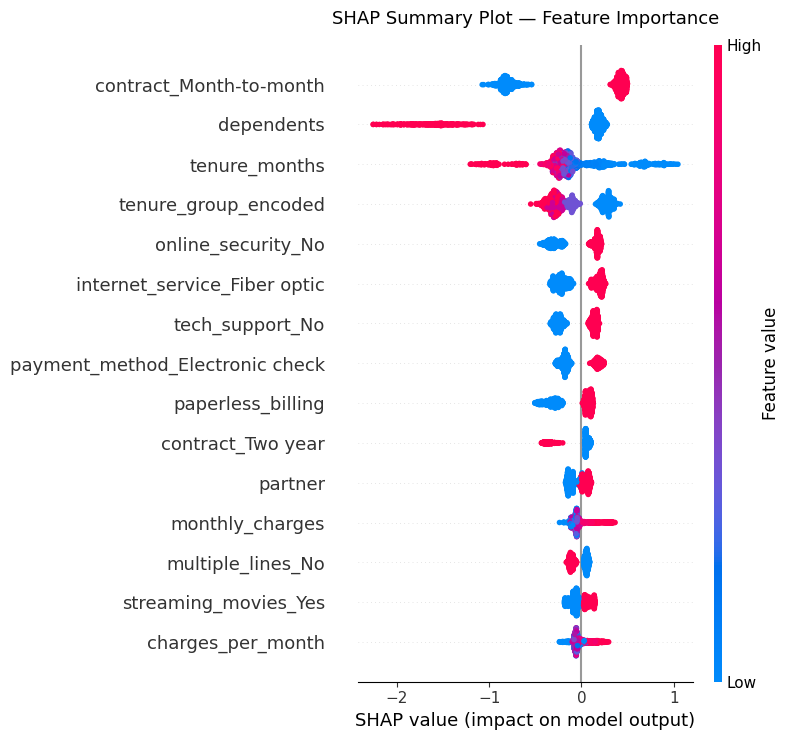

Saved to reports/figures/shap_summary.png


In [7]:
# The summary plot shows two things at once:
# 1. Feature importance (vertical axis — most important at top)
# 2. Direction of effect (red = high value increases churn risk, blue = decreases it)
# 3. Spread of values (wider scatter = more varied impact)

plt.figure()
shap.summary_plot(
    shap_values,
    X_test_transformed_df,
    max_display=15,      # show top 15 most important features
    show=False           # don't show yet — save first
)
plt.title('SHAP Summary Plot — Feature Importance', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to reports/figures/shap_summary.png")

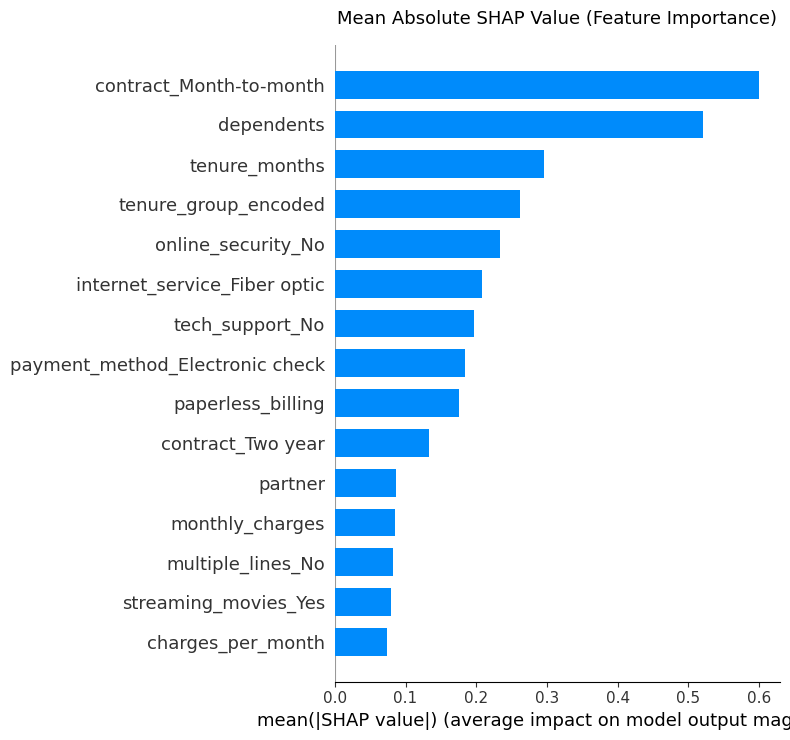

In [8]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_transformed_df,
    plot_type='bar',    # average absolute SHAP value per feature
    max_display=15,
    show=False
)
plt.title('Mean Absolute SHAP Value (Feature Importance)', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../reports/figures/shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

Explaining prediction for test customer #1090
Predicted churn probability: 94.4%
Actual outcome: Churned



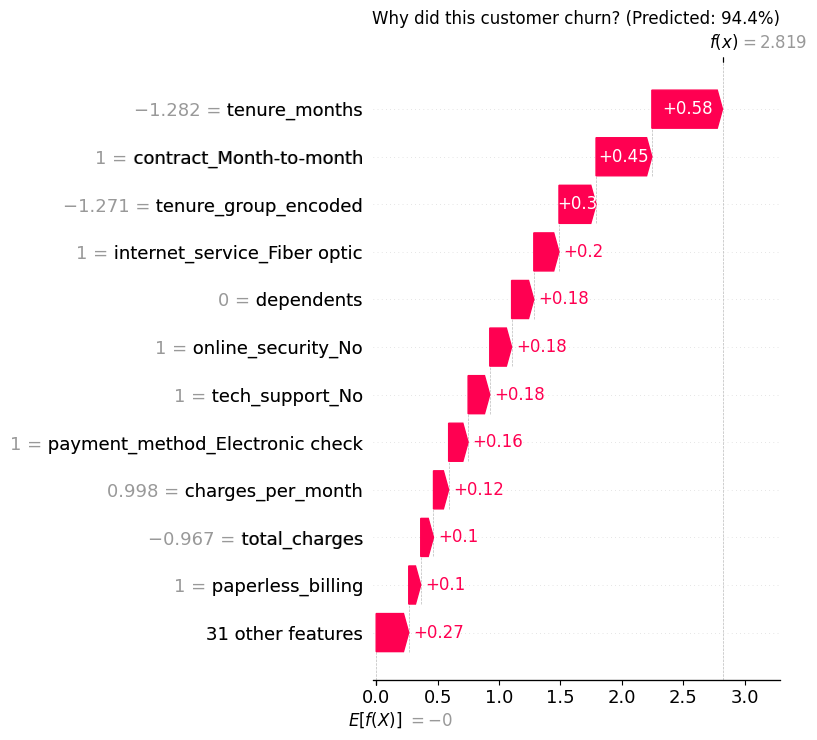

In [9]:
# Find a customer the model predicted as HIGH churn risk
# predict_proba returns [prob_no_churn, prob_churn] for each customer
churn_probs = best_pipeline.predict_proba(X_test)[:, 1]

# Sort by churn probability and pick the customer with highest predicted risk
highest_risk_idx = churn_probs.argmax()
predicted_prob = churn_probs[highest_risk_idx]
actual_label = y_test.iloc[highest_risk_idx]

print(f"Explaining prediction for test customer #{highest_risk_idx}")
print(f"Predicted churn probability: {predicted_prob:.1%}")
print(f"Actual outcome: {'Churned' if actual_label == 1 else 'Did not churn'}")
print()

# Create SHAP Explanation object for this one customer
explanation = shap.Explanation(
    values=shap_values[highest_risk_idx],
    base_values=explainer.expected_value,
    data=X_test_transformed_df.iloc[highest_risk_idx],
    feature_names=feature_names
)

# Waterfall plot: shows which features pushed the prediction UP or DOWN
# Red bars push probability higher (toward churn)
# Blue bars push probability lower (away from churn)
# The bars start from the "base value" (average prediction across all customers)
plt.figure()
shap.waterfall_plot(explanation, max_display=12, show=False)
plt.title(f'Why did this customer churn? (Predicted: {predicted_prob:.1%})', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/figures/shap_waterfall_high_risk.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1000x600 with 0 Axes>

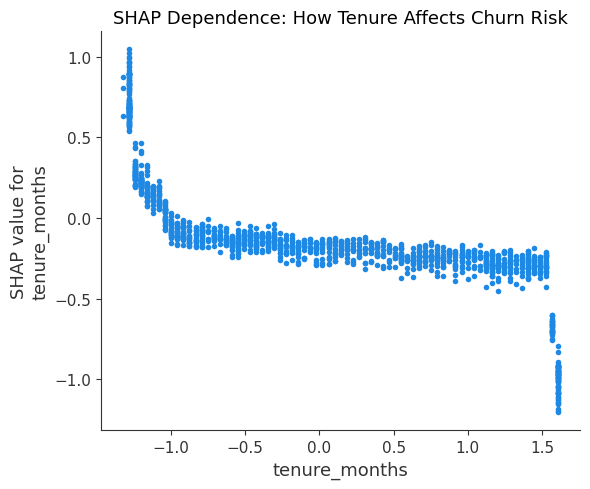


How to read this plot:
X-axis: the customer's actual tenure in months
Y-axis: how much tenure PUSHED the churn probability (positive = toward churn)
Customers on the left (low tenure) have HIGH positive SHAP values = higher churn risk


In [10]:
# Dependence plot: x-axis = tenure_months value, y-axis = SHAP value for that customer
# Each dot is one customer in the test set
# Red dots = customers on Month-to-month contracts
# This often reveals that short-tenure + month-to-month = extreme churn risk

tenure_idx = feature_names.index('tenure_months')

plt.figure(figsize=(10, 6))
shap.dependence_plot(
    tenure_idx,
    shap_values,
    X_test_transformed_df,
    feature_names=feature_names,
    interaction_index=None,   # no interaction coloring for simplicity
    show=False
)
plt.title('SHAP Dependence: How Tenure Affects Churn Risk', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/shap_dependence_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nHow to read this plot:")
print("X-axis: the customer's actual tenure in months")
print("Y-axis: how much tenure PUSHED the churn probability (positive = toward churn)")
print("Customers on the left (low tenure) have HIGH positive SHAP values = higher churn risk")

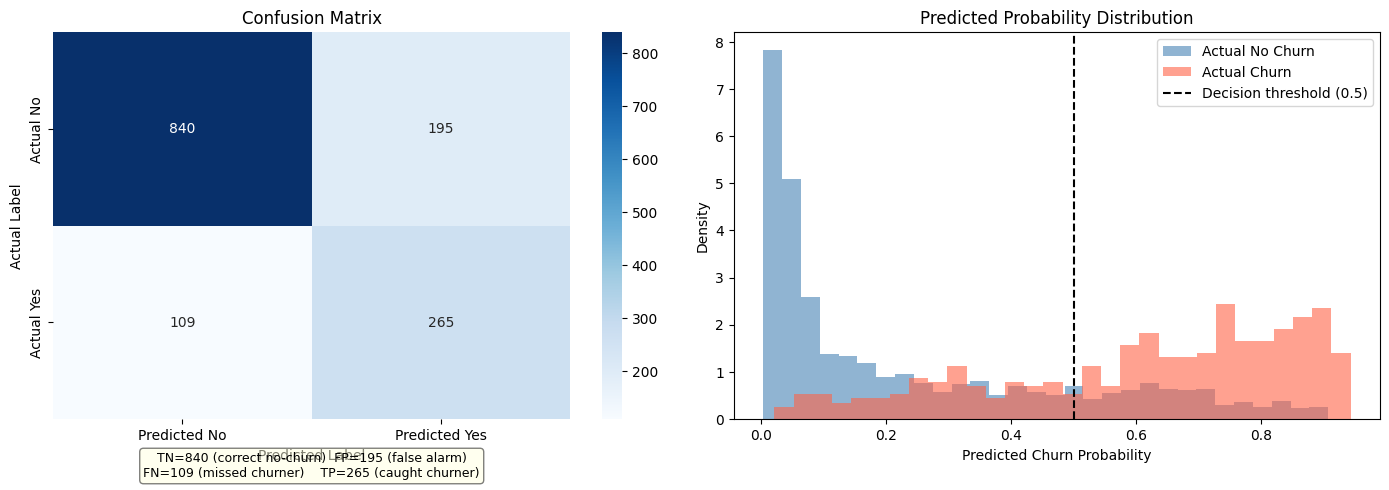


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.89      0.81      0.85      1035
       Churn       0.58      0.71      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409



In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = best_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted No', 'Predicted Yes'],
    yticklabels=['Actual No', 'Actual Yes'],
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

# Add annotations explaining each quadrant
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.15,
    f'TN={tn} (correct no-churn)  FP={fp} (false alarm)\n'
    f'FN={fn} (missed churner)    TP={tp} (caught churner)',
    transform=axes[0].transAxes, ha='center', fontsize=9,
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5)
)

# Churn probability distribution
axes[1].hist(churn_probs[y_test == 0], bins=30, alpha=0.6,
             color='steelblue', label='Actual No Churn', density=True)
axes[1].hist(churn_probs[y_test == 1], bins=30, alpha=0.6,
             color='tomato', label='Actual Churn', density=True)
axes[1].axvline(x=0.5, color='black', linestyle='--', label='Decision threshold (0.5)')
axes[1].set_title('Predicted Probability Distribution')
axes[1].set_xlabel('Predicted Churn Probability')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))